# Data Science Project - Exploratory Analysis of Wine Quality Factors

##1.0 Dataset and its Properties

###1.1 Dataset Upload - from Kaggle

In [6]:
from google.colab import files
files.upload()  # Upload kaggle.json here

Saving winequality-red.csv to winequality-red (1).csv
Saving winequality-white.csv to winequality-white (1).csv


{'winequality-red (1).csv': b'fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality\n7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5\n7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.2,0.68,9.8,5\n7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5\n11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6\n7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5\n7.4,0.66,0.0,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5\n7.9,0.6,0.06,1.6,0.069,15.0,59.0,0.9964,3.3,0.46,9.4,5\n7.3,0.65,0.0,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7\n7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7\n7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5,5\n6.7,0.58,0.08,1.8,0.09699999999999999,15.0,65.0,0.9959,3.28,0.54,9.2,5\n7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5,5\n5.6,0.615,0.0,1.6,0.08900000000000001,16.0,59.0,0.9943,3.58,0.52,9.9,5\n7.8,0.61,0.29,1.6,0.114,9.0,29.0,0.9974,3.26,1.56,9.

In [7]:
import os
import zipfile

# Create the Kaggle folder and move kaggle.json there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [8]:
!kaggle datasets download -d rajyellow46/wine-quality

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 1734, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [9]:
!unzip wine-quality.zip

unzip:  cannot find or open wine-quality.zip, wine-quality.zip.zip or wine-quality.zip.ZIP.


In [ ]:
# Print the unique values in the 'type' column
print("Distinct wine types in the dataset:")
print(df['type'].unique())

Distinct wine types in the dataset:
['white' 'red']


###1.2 Initian Data Inspection



In [ ]:
print("Dataset Shape (rows, columns):")
df.shape

Dataset Shape (rows, columns):


(6497, 13)

In [ ]:
print("Column names:")
df.columns

Column names:


Index(['type', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='object')

In [ ]:
print("Data types")
df.dtypes

Data types


,0
type,object
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64


In [ ]:
# Summary statistics for numerical columns
print("Summary statistics:")
df.describe()

Summary statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
# Check for missing values
print("Missing values per column :")
df.isnull().sum()

Missing values per column :


,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<ipython-input-13-73eb32ee3138>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


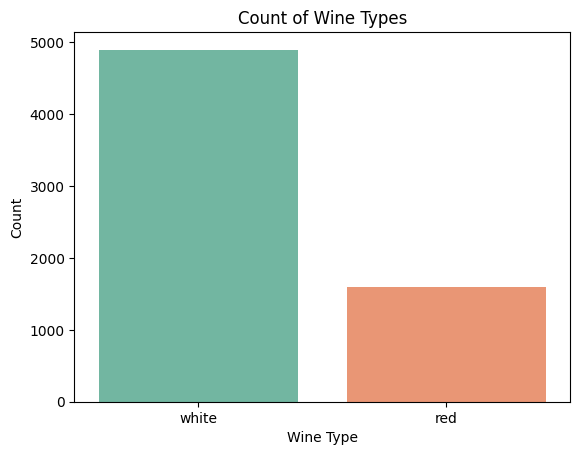

In [ ]:
# 1.1 Distribution of Wine Types (Separate Block for Better Readability)
sns.countplot(x='type', data=df, palette='Set2')
plt.title('Count of Wine Types')
plt.xlabel('Wine Type')
plt.ylabel('Count')
plt.show()

In [ ]:
# Unique values in 'type' column (if exists)
if 'type' in df.columns:
    print("\nUnique wine types:", df['type'].unique())
    print("Counts of each type:\n", df['type'].value_counts())


Unique wine types: ['white' 'red']
Counts of each type:
 type
white    4898
red      1599
Name: count, dtype: int64


##2.0 Exploratory Data Analysis


###2.1 Data Cleaning :


In [ ]:
# Check for missing values
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [ ]:
import numpy as np

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
# impute the missing values using the mean
imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [ ]:
import numpy as np

###2.2 Removing outliers

In [ ]:
# Step 1: Select numeric columns only

In [ ]:
from scipy.stats import zscore
z_scores = np.abs(zscore(df[numeric_cols]))

In [ ]:
# Count how many z-scores in a row exceed threshold
outlier_count = (z_scores > 3).sum(axis=1)

In [ ]:
# Keep rows where the count of high-z-score columns is small
df = df[outlier_count <= 1]

In [ ]:
print("After removing outliers:", df.shape)

After removing outliers: (6434, 13)


Before : 6497 --- After outlier removal : 6434

###2.3 Feature Engineering

Feature engineering is the process of transforming raw data into meaningful input features that improve the performance of machine learning models.

In [ ]:
def categorize_quality(score):
    if score <= 4:
        return 'Low'
    elif 5 <= score <= 6:
        return 'Medium'
    else:
        return 'High'

In [ ]:
df['Quality Label'] = df['quality'].apply(categorize_quality)
print(df['Quality Label'].value_counts())

Quality Label
Medium    4933
High      1273
Low        228
Name: count, dtype: int64


<ipython-input-30-fae22dccab6e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quality Label'] = df['quality'].apply(categorize_quality)


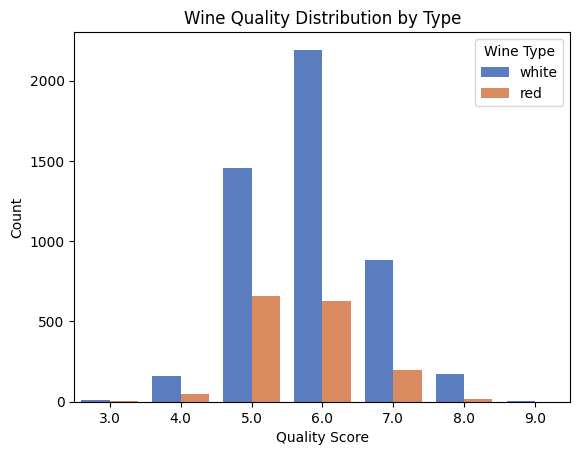

In [ ]:
sns.countplot(x='quality', data=df, palette='muted', hue='type')
plt.title('Wine Quality Distribution by Type')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.legend(title='Wine Type')
plt.show()

###2.4 Feature Distribution

<ipython-input-32-84fbc3260d6e>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='alcohol', data=df, palette='pastel')


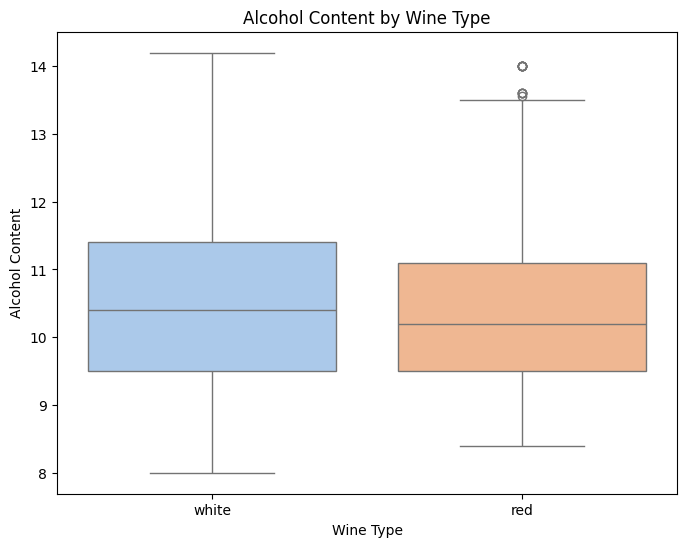

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='type', y='alcohol', data=df, palette='pastel')
plt.title('Alcohol Content by Wine Type')
plt.xlabel('Wine Type')
plt.ylabel('Alcohol Content')
plt.show()

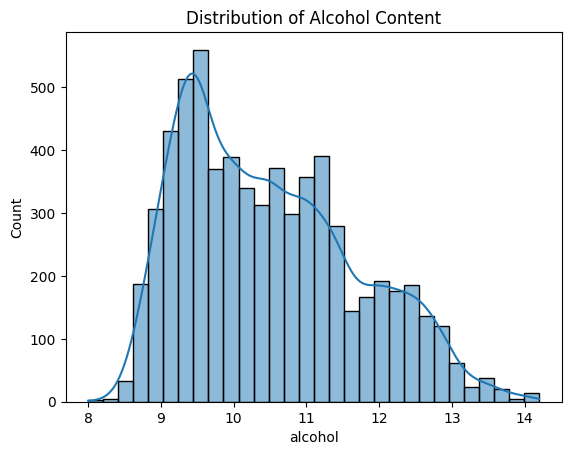

In [ ]:
sns.histplot(df['alcohol'], kde=True, bins=30)
plt.title('Distribution of Alcohol Content')
plt.show()

In [ ]:
# Grouped statistics
df.groupby('type').mean(numeric_only=True).T

type,red,white
fixed acidity,8.298990,6.853048
volatile acidity,0.523176,0.277950
citric acid,0.266462,0.333625
residual sugar,2.539175,6.369662
chlorides,0.082709,0.045647
free sulfur dioxide,15.927835,35.191008
total sulfur dioxide,46.424613,138.110713
density,0.996724,0.994009
pH,3.314424,3.188386
sulphates,0.649170,0.489736


###2.5 Feature Importance / Correlation with Target


Examine how features are correlated with each other and with quality (target variable):


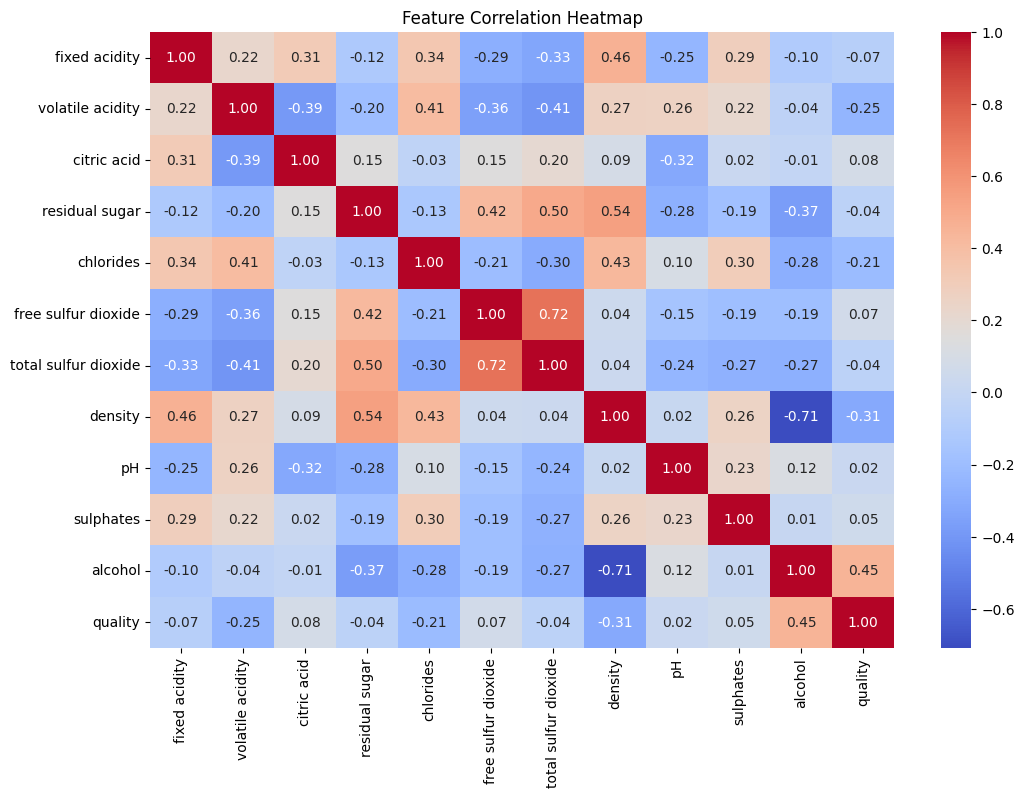

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

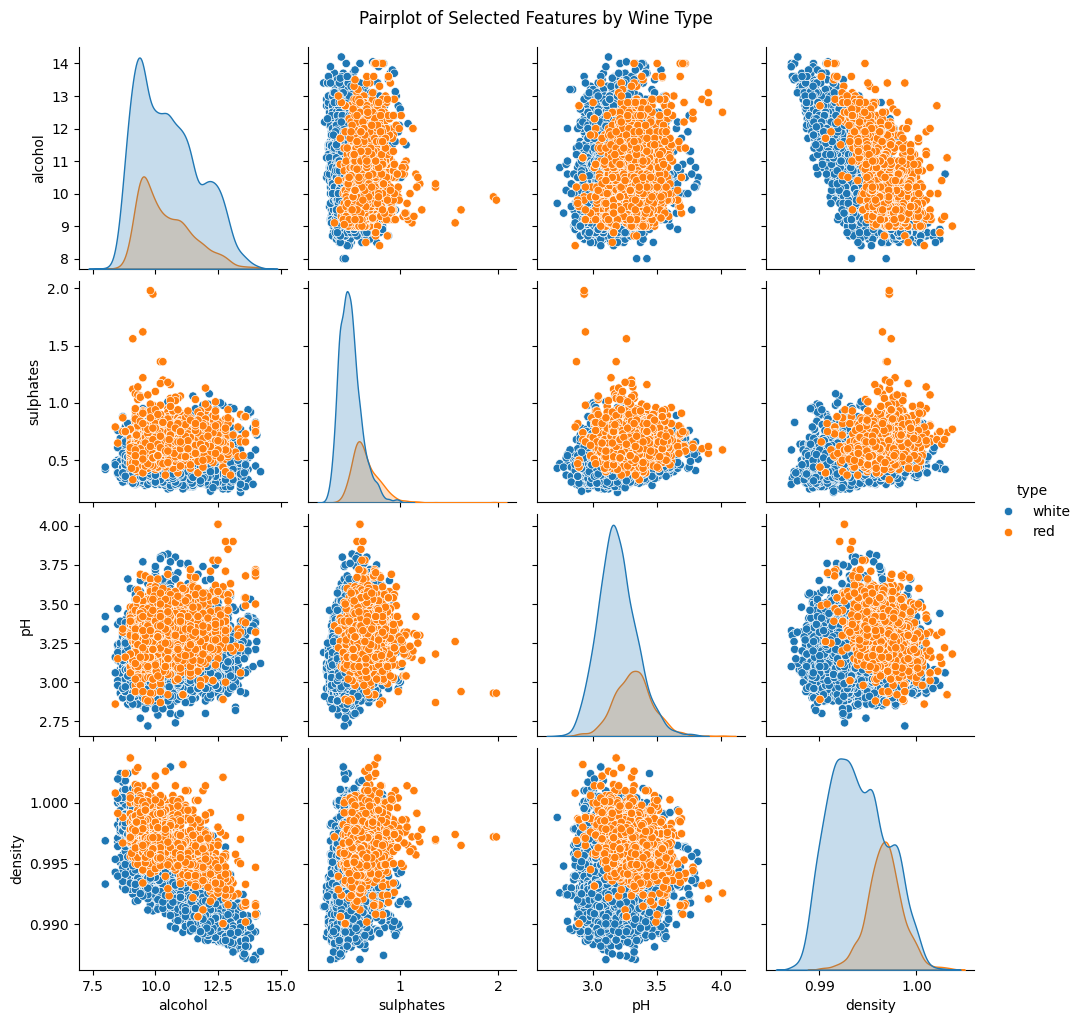

In [ ]:
sns.pairplot(df, hue='type', vars=['alcohol', 'sulphates', 'pH', 'density'])
plt.suptitle('Pairplot of Selected Features by Wine Type', y=1.02)
plt.show()

###2.6 Feature Scaling

Standardizing the features ensures that all numeric inputs are on the same scale, which is crucial for algorithms like logistic regression or PCA

In [ ]:
X = df.drop(columns=['quality', 'Quality Label', 'type'])
y = df['Quality Label']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###2.7 Target Variable Distribution

<ipython-input-39-2e701b4b80fe>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


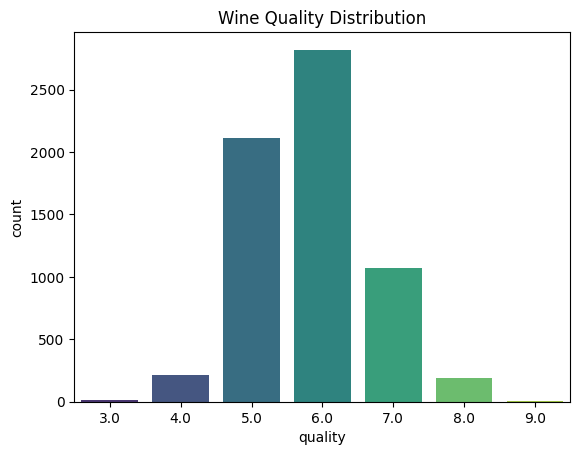

In [ ]:
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Wine Quality Distribution')
plt.show()

###2.8 Principal Component Analysis - To reduce dimension + capture max variance

Assume , I want to reduce dimensions + capture 95% of the variance



####2.8.1 How ?

1. Select the numeric features
2. Standardize the features
3. Apply PCA
4. Plot

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=0.95) # i want to capture 95 % of the variance
X_pca = pca.fit_transform(X_scaled)

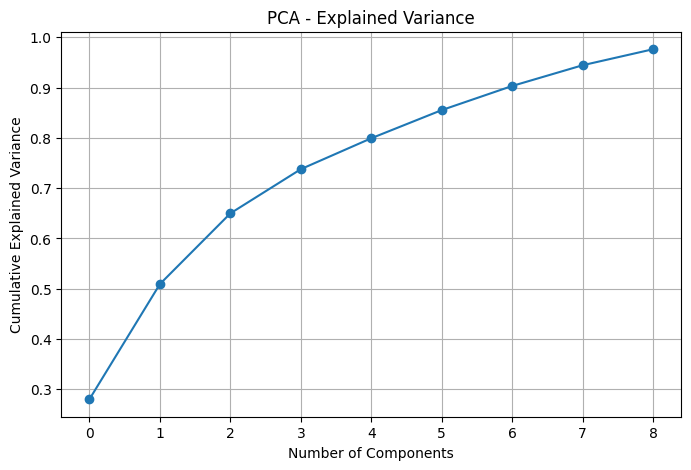

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.grid(True)
plt.show()

This tells us that 95% of the variance can be captured using 8 out of the 14 dimensions (in the original dataset)

This is the variance distribution of the different components (dimensions) if we want to see

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

####2.8.2 Why did we perform PCA ?

1. Dimensionality reduction + capturing maximum variance
2. 2D visualization + separation b/w red and white wine data in PCA space
3. Explained variance
4. Direction of Variation


In [ ]:
pca.explained_variance_ratio_

array([0.28035002, 0.22899939, 0.14059307, 0.0878617 , 0.06151109,
       0.05596866, 0.04799418, 0.0412062 , 0.03185741])

In [ ]:
print(pca.components_)

[[-0.23380636 -0.38184647  0.17403454  0.3473849  -0.29728018  0.42800641
   0.48164155 -0.04714557 -0.232781   -0.27811296 -0.10612948]
 [ 0.32722022  0.12824758  0.14685785  0.32778256  0.32908713  0.07872886
   0.08755509  0.5941231  -0.12832217  0.16086982 -0.47956277]
 [ 0.47642196 -0.28058028  0.5902045  -0.14726352 -0.04881786 -0.15950092
  -0.12975473 -0.12799965 -0.45333389  0.06498582  0.23127955]
 [-0.08387024 -0.23999051  0.29346758 -0.10565489  0.04057072  0.29279851
   0.16376229  0.01391658  0.48029648  0.69134513  0.12268929]
 [-0.07252252  0.03687963  0.06209035 -0.49833124  0.65930376  0.33343706
   0.19907175 -0.26401338 -0.14177932 -0.19140391 -0.17105546]
 [-0.157755   -0.45197549  0.31284419 -0.08966046  0.08129987 -0.36079064
  -0.18447287  0.09897981  0.45487755 -0.38504125 -0.35936595]
 [ 0.14077933  0.42891653  0.39898107  0.21032546  0.10743561  0.20099572
   0.04947287  0.08474229  0.38363989 -0.42300105  0.45288975]
 [-0.45871917 -0.16402031  0.05015224  0.